In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load
df = pd.read_csv('../data/raw/PJM_Load_hourly.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)
df = df.rename(columns={'PJM_Load_MW': 'energy_mw'})

# Fix DST gaps
df = df.set_index('Datetime')
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
df = df.reindex(full_range)
df['energy_mw'] = df['energy_mw'].interpolate(method='linear')
df.index.name = 'Datetime'
df = df.reset_index()

print(f"Shape: {df.shape}")
print(f"Missing values: {df['energy_mw'].isna().sum()}")
df.head()


Shape: (32904, 2)
Missing values: 0


,Datetime,energy_mw
0,1998-04-01 01:00:00,22259.0
1,1998-04-01 02:00:00,21244.0
2,1998-04-01 03:00:00,20651.0
3,1998-04-01 04:00:00,20421.0
4,1998-04-01 05:00:00,20713.0


In [4]:
def build_features(df):
    df = df.copy()
    
    # 1. Calendar features
    df['hour'] = df['Datetime'].dt.hour
    df['dayofweek'] = df['Datetime'].dt.dayofweek
    df['month'] = df['Datetime'].dt.month
    df['quarter'] = df['Datetime'].dt.quarter
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    
    # 2. Lag features
    df['lag_24']  = df['energy_mw'].shift(24)
    df['lag_48']  = df['energy_mw'].shift(48)
    df['lag_168'] = df['energy_mw'].shift(168)
    
    # 3. Rolling statistics
    df['rolling_mean_24']  = df['energy_mw'].shift(1).rolling(24).mean()
    df['rolling_mean_168'] = df['energy_mw'].shift(1).rolling(168).mean()
    df['rolling_std_24']   = df['energy_mw'].shift(1).rolling(24).std()
    
    # 4. Fourier terms (daily and weekly cycles)
    df['sin_hour']   = np.sin(2 * np.pi * df['hour'] / 24)
    df['cos_hour']   = np.cos(2 * np.pi * df['hour'] / 24)
    df['sin_week']   = np.sin(2 * np.pi * df['Datetime'].dt.dayofyear / 7)
    df['cos_week']   = np.cos(2 * np.pi * df['Datetime'].dt.dayofyear / 7)
    df['sin_month']  = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month']  = np.cos(2 * np.pi * df['month'] / 12)
    
    # Drop rows with NaN from lag features
    df = df.dropna().reset_index(drop=True)
    
    return df

df_features = build_features(df)

print(f"Shape after features: {df_features.shape}")
print(f"\nFeature columns:")
print([c for c in df_features.columns if c not in ['Datetime', 'energy_mw']])
df_features.head(3)

Shape after features: (32736, 19)

Feature columns:
['hour', 'dayofweek', 'month', 'quarter', 'is_weekend', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24', 'sin_hour', 'cos_hour', 'sin_week', 'cos_week', 'sin_month', 'cos_month']


,Datetime,energy_mw,hour,dayofweek,month,quarter,is_weekend,lag_24,lag_48,lag_168,rolling_mean_24,rolling_mean_168,rolling_std_24,sin_hour,cos_hour,sin_week,cos_week,sin_month,cos_month
0,1998-04-08 01:00:00,21698.0,1,2,4,2,0,22323.0,21760.0,22259.0,26776.875000,25893.961310,3171.533072,0.258819,0.965926,-3.429011e-15,1.0,0.866025,-0.5
1,1998-04-08 02:00:00,20826.0,2,2,4,2,0,21483.0,20634.0,21244.0,26750.833333,25890.622024,3212.001945,0.500000,0.866025,-3.429011e-15,1.0,0.866025,-0.5
2,1998-04-08 03:00:00,20279.0,3,2,4,2,0,21211.0,20535.0,20651.0,26723.458333,25888.133929,3261.272064,0.707107,0.707107,-3.429011e-15,1.0,0.866025,-0.5


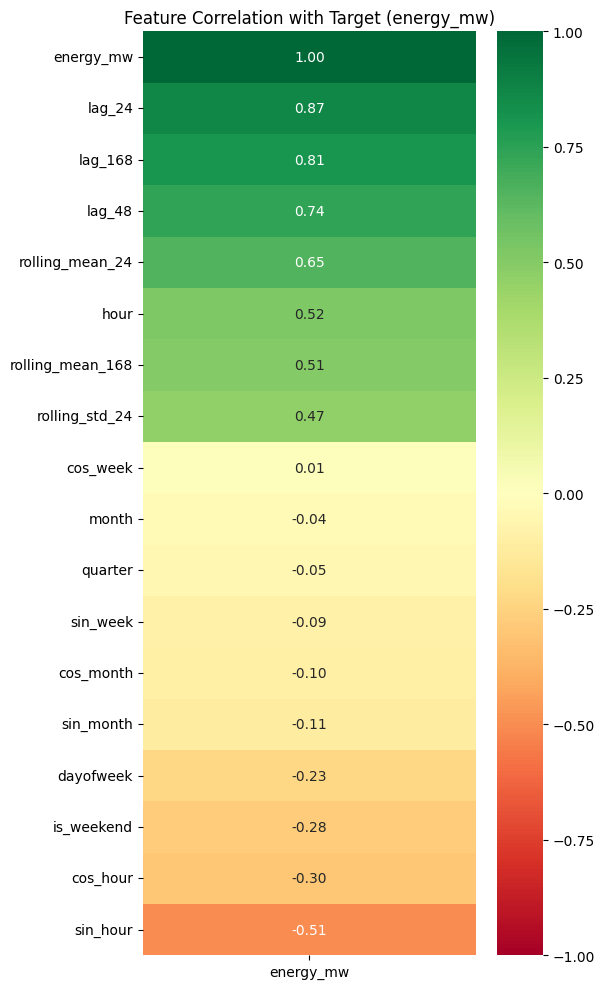

In [5]:
import seaborn as sns

feature_cols = [c for c in df_features.columns if c not in ['Datetime']]
corr = df_features[feature_cols].corr()[['energy_mw']].sort_values('energy_mw', ascending=False)

fig, ax = plt.subplots(figsize=(6, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation with Target (energy_mw)')
plt.tight_layout()
plt.show()

## Feature Correlation Analysis
- lag_24 (0.87) and lag_168 (0.81) are the strongest predictors;
- Lag features dominate — model will heavily rely on recent history;
- is_weekend (-0.28) confirms the weekday/weekend split;
- Fourier terms have moderate correlation — useful for smooth cycle encoding.